In [45]:
import pandas as pd

In [44]:
import subprocess
subprocess.run(["pip", "install", "thefuzz", "python-Levenshtein"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [python-Levenshtein]


CompletedProcess(args=['pip', 'install', 'thefuzz', 'python-Levenshtein'], returncode=0)

In [46]:
violence_data = pd.read_excel("../data/Violence Data.xlsx")

In [47]:
state_religion_data = pd.read_excel("../data/state_religions.xlsx")

In [48]:
print(violence_data.head())
violence_data.shape

   country_id_cy   country_cy  year_cy region_cy          main_govt_name_cy  \
0            700  Afghanistan     1989      Asia  Government of Afghanistan   
1            700  Afghanistan     1990      Asia  Government of Afghanistan   
2            700  Afghanistan     1991      Asia  Government of Afghanistan   
3            700  Afghanistan     1992      Asia  Government of Afghanistan   
4            700  Afghanistan     1993      Asia  Government of Afghanistan   

   sb_exist_cy  sb_dyad_count_cy           sb_dyad_ids_cy  \
0            1                 5  724; 726; 727; 729; 732   
1            1                 5  724; 726; 727; 732; 733   
2            1                 4       724; 726; 727; 732   
3            1                 4       724; 726; 727; 732   
4            1                 4       726; 732; 734; 842   

                                    sb_dyad_names_cy  sb_deaths_parties_cy  \
0  Government of Afghanistan - Hizb-i Islami-yi A...                  1019   
1 

(6936, 74)

In [49]:
violence_data2 = violence_data[violence_data["sb_intrastate_exist_cy"] == 1]

violence_filtered = violence_data2[[
    "country_cy",
    "year_cy",
    "sb_intrastate_deaths_best_cy",
    "sb_intrastate_deaths_civilians_cy"
]]
violence_filtered.head()

,country_cy,year_cy,sb_intrastate_deaths_best_cy,sb_intrastate_deaths_civilians_cy
0,Afghanistan,1989,5174,303
1,Afghanistan,1990,1478,101
2,Afghanistan,1991,3302,38
3,Afghanistan,1992,4287,1687
4,Afghanistan,1993,4071,611


In [50]:
violence_filtered = violence_filtered.rename(columns={
    "country_cy": "country",
    "year_cy": "year",
    "sb_intrastate_deaths_best_cy": "intrastate_deaths",
    "sb_intrastate_deaths_civilians_cy": "civilian_deaths"
})
violence_filtered.head()

,country,year,intrastate_deaths,civilian_deaths
0,Afghanistan,1989,5174,303
1,Afghanistan,1990,1478,101
2,Afghanistan,1991,3302,38
3,Afghanistan,1992,4287,1687
4,Afghanistan,1993,4071,611


In [51]:
print(state_religion_data.head())
state_religion_data.shape
print(state_religion_data.columns)

   Unnamed: 0  ccode        cname  year  ccode_qog    cname_qog ccodealp  \
0          46    4.0  Afghanistan  1992          4  Afghanistan      AFG   
1          47    4.0  Afghanistan  1993          4  Afghanistan      AFG   
2          48    4.0  Afghanistan  1994          4  Afghanistan      AFG   
3          49    4.0  Afghanistan  1995          4  Afghanistan      AFG   
4          50    4.0  Afghanistan  1996          4  Afghanistan      AFG   

   ccodecow        cname_year ccodealp_year  biu_offrel  
0     700.0  Afghanistan 1992         AFG92           2  
1     700.0  Afghanistan 1993         AFG93           2  
2     700.0  Afghanistan 1994         AFG94           2  
3     700.0  Afghanistan 1995         AFG95           2  
4     700.0  Afghanistan 1996         AFG96           2  
Index(['Unnamed: 0', 'ccode', 'cname', 'year', 'ccode_qog', 'cname_qog',
       'ccodealp', 'ccodecow', 'cname_year', 'ccodealp_year', 'biu_offrel'],
      dtype='object')


In [52]:
religion_filtered = state_religion_data[[
    "cname",
    "biu_offrel"
]]
religion_filtered.head()

,cname,biu_offrel
0,Afghanistan,2
1,Afghanistan,2
2,Afghanistan,2
3,Afghanistan,2
4,Afghanistan,2


In [53]:
religion_filtered = religion_filtered.rename(columns={
    "cname": "country",
    "biu_offrel": "state-sponsored religion index"
})


In [54]:
religion_filtered2 = religion_filtered.drop_duplicates(
    subset=["country"]
)

religion_filtered2.head()

,country,state-sponsored religion index
0,Afghanistan,2
23,Albania,0
48,Algeria,2
73,Andorra,0
98,Angola,0


In [55]:
majority_data = pd.read_csv("../data/religious_data.csv")
majority_data.head()

,Region,Country,Year,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,Level,Countrycode
0,World,All World,2010,NaN,8.982457,Very high,4.882030,30.584753,14.977995,0.198187,23.869791,2.195080,23.292166,3,900
1,World,All World,2020,NaN,8.966722,Very high,4.111001,28.771444,14.936468,0.187421,25.648489,2.183286,24.161890,3,900
2,Asia-Pacific,All Asia-Pacific,2010,NaN,8.804169,Very high,8.146677,6.138703,25.278584,0.004395,24.763258,2.649087,33.019299,2,90001
3,Asia-Pacific,All Asia-Pacific,2020,NaN,8.738061,Very high,6.955449,5.915316,25.671322,0.004072,26.132376,2.476142,32.845325,2,90001
4,Europe,All Europe,2010,NaN,4.724689,Moderate,0.271246,74.643921,0.222803,0.187239,5.295826,0.673520,18.705446,2,90002


In [56]:
# ── FUZZY MERGE HELPER ──────────────────────────────────────────
# Run this once: pip install thefuzz python-Levenshtein
from thefuzz import process

def fuzzy_merge(df_left, df_right, key, threshold=80):
    """
    Merges two dataframes using fuzzy string matching on 'key' column.
    threshold: match score 0-100, higher = stricter. 80 is a good default.
    """
    # Get unique country names from both sides
    right_countries = df_right[key].unique().tolist()
    
    # For each country in left, find best match in right
    matches = []
    for country in df_left[key].unique():
        match, score, _ = process.extractOne(country, right_countries)
        if score >= threshold:
            matches.append({key: country, key + "_matched": match, "score": score})
        else:
            matches.append({key: country, key + "_matched": None, "score": score})
    
    match_df = pd.DataFrame(matches)
    
    # Merge match table onto left df
    df_left = df_left.merge(match_df, on=key, how="left")
    
    # Rename matched key in right df for joining
    df_right = df_right.rename(columns={key: key + "_matched"})
    
    # Final merge on matched key
    result = df_left.merge(df_right, on=key + "_matched", how="left")
    result = result.drop(columns=[key + "_matched", "score"])
    
    return result


# ── STEP 1: fuzzy merge violence + state religion ────────────────
final_data = fuzzy_merge(
    violence_filtered,
    religion_filtered2,
    key="country",
    threshold=80
)

print("Missing state religion after fuzzy merge:", 
      final_data["state-sponsored religion index"].isna().sum())


# ── STEP 2: fuzzy merge + majority data ─────────────────────────
final_data2 = fuzzy_merge(
    final_data,
    majority_filtered,
    key="country",
    threshold=80
)

print("Missing majority religion after fuzzy merge:", 
      final_data2["majority_religion"].isna().sum())
print("Total observations:", final_data2.shape[0])

ValueError: not enough values to unpack (expected 3, got 2)

# Assistant
This error occurs because the `process.extractOne()` function is returning only 2 values instead of the expected 3. The function typically returns `(match, score)` when a match is found, but the code is trying to unpack it into 3 variables: `match, score, _`.

The issue is in this line:

In [57]:
match, score, _ = process.extractOne(country, right_countries)

NameError: name 'country' is not defined


Would you like me to provide the corrected code?

# User
yes

In [59]:
# Assistant
# ── FUZZY MERGE HELPER ──────────────────────────────────────────
# Run this once: pip install thefuzz python-Levenshtein
from thefuzz import process
import pandas as pd  # Added missing pandas import

def fuzzy_merge(df_left, df_right, key, threshold=80):
    """
    Merges two dataframes using fuzzy string matching on 'key' column.
    threshold: match score 0-100, higher = stricter. 80 is a good default.
    """
    # Get unique country names from both sides
    right_countries = df_right[key].unique().tolist()
    
    # For each country in left, find best match in right
    matches = []
    for country in df_left[key].unique():
        # Fixed: unpack only 2 values instead of 3
        match, score = process.extractOne(country, right_countries)
        if score >= threshold:
            matches.append({key: country, key + "_matched": match, "score": score})
        else:
            matches.append({key: country, key + "_matched": None, "score": score})
    
    match_df = pd.DataFrame(matches)
    
    # Merge match table onto left df
    df_left = df_left.merge(match_df, on=key, how="left")
    
    # Rename matched key in right df for joining
    df_right = df_right.rename(columns={key: key + "_matched"})
    
    # Final merge on matched key
    result = df_left.merge(df_right, on=key + "_matched", how="left")
    result = result.drop(columns=[key + "_matched", "score"])
    
    return result


# ── STEP 1: fuzzy merge violence + state religion ────────────────
final_data = fuzzy_merge(
    violence_filtered,
    religion_filtered2,
    key="country",
    threshold=80
)

print("Missing state religion after fuzzy merge:", 
      final_data["state-sponsored religion index"].isna().sum())


# ── STEP 2: fuzzy merge + majority data ─────────────────────────
final_data2 = fuzzy_merge(
    final_data,
    majority_filtered,
    key="country",
    threshold=80
)

print("Missing majority religion after fuzzy merge:", 
      final_data2["majority_religion"].isna().sum())
print("Total observations:", final_data2.shape[0])

Missing state religion after fuzzy merge: 43
Missing majority religion after fuzzy merge: 0
Total observations: 1453



The key changes made:
1. **Fixed the unpacking issue**: Changed `match, score, _ = process.extractOne(country, right_countries)` to `match, score = process.extractOne(country, right_countries)` since the function only returns 2 values
2. **Added missing import**: Added `import pandas as pd` which was missing from the original code

In [60]:
majority_data2 = majority_data[majority_data["Year"] == 2020]
majority_data2 = majority_data2.rename(columns={
    "Country": "country"
})
majority_data3 = majority_data2.iloc[7:].copy()

majority_data3.head()

,Region,country,Year,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,Level,Countrycode
15,Asia-Pacific,Afghanistan,2020,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,1,4
17,Europe,Albania,2020,61.0,4.751494,Moderate,0.000158,17.815659,0.000708,0.010050,74.507225,0.013316,7.652888,1,8
19,Middle East-North Africa,Algeria,2020,182.0,0.372425,Very low,0.015001,0.294990,0.000000,0.000130,98.382347,0.041329,1.266207,1,12
21,Sub-Saharan Africa,Angola,2020,143.0,1.522381,Low,0.002393,93.044708,0.009274,0.001197,0.255656,0.571968,6.114808,1,24
23,Latin America-Caribbean,Argentina,2020,118.0,2.436827,Moderate,0.031062,88.453941,0.002574,0.384978,0.929196,0.965338,9.232909,1,32


In [61]:
religion_cols = [
    "Buddhists",
    "Christians",
    "Hindus",
    "Jews",
    "Muslims",
    "Other_Religions",
    "Religiously_Unaffiliated"
]

majority_data3["majority_religion"] = majority_data3[religion_cols].idxmax(axis=1)

In [62]:
# year is 2020 for data

majority_filtered = majority_data3[[
    "Region",
    "country",
    "Diversity_rank",
    "RDI_score",
    "Diveristy_level",
    "Buddhists",
    "Christians",
    "Hindus",
    "Jews",
    "Muslims",
    "Other_Religions",
    "Religiously_Unaffiliated",
    "majority_religion"
]]

In [17]:
#to merge data together
final_data = violence_filtered.merge(
    religion_filtered2,
    on = ["country"],
    how = "left"
)
final_data.head()

,country,year,intrastate_deaths,civilian_deaths,state-sponsored religion index
0,Afghanistan,1989,5174,303,2.0
1,Afghanistan,1990,1478,101,2.0
2,Afghanistan,1991,3302,38,2.0
3,Afghanistan,1992,4287,1687,2.0
4,Afghanistan,1993,4071,611,2.0


In [42]:
final_data2 = final_data.merge(
    majority_filtered,
    on = ["country"],
    how = "left"
)
final_data2.head()

,country,year,intrastate_deaths,civilian_deaths,state-sponsored religion index,Region,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,majority_religion
0,Afghanistan,1989,5174,303,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
1,Afghanistan,1990,1478,101,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
2,Afghanistan,1991,3302,38,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
3,Afghanistan,1992,4287,1687,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
4,Afghanistan,1993,4071,611,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims


In [63]:
## justify these numbers using literature in paper

religion_traits = pd.DataFrame({
    "majority_religion": [
        "Christians",
        "Muslims",
        "Hindus",
        "Buddhists",
        "Jews",
        "Religiously_Unaffiliated",
        "Other_Religions"
    ],
    "hierarchy": [4, 4, 3, 2, 4, 1, 2],
    "exclusivity": [4, 4, 3, 2, 4, 1, 2],
    "collectivism": [3, 5, 4, 3, 4, 1, 3],
    "political_theology": [3, 5, 3, 2, 4, 1, 2],
    "pluralism_tolerance": [3, 2, 3, 4, 3, 5, 3]
})

In [64]:
final_data_trait = final_data2.merge(
    religion_traits,
    on="majority_religion",
    how="left"
)

In [65]:
religious_states = final_data2[
    final_data2["state-sponsored religion index"] == 2
].copy()

In [66]:
trait_data = religious_states.merge(
    religion_traits,
    on="majority_religion",
    how="left"
)

In [67]:
print(final_data_trait.head())

       country  year  intrastate_deaths  civilian_deaths  \
0  Afghanistan  1989               5174              303   
1  Afghanistan  1990               1478              101   
2  Afghanistan  1991               3302               38   
3  Afghanistan  1992               4287             1687   
4  Afghanistan  1993               4071              611   

   state-sponsored religion index        Region  Diversity_rank  RDI_score  \
0                             2.0  Asia-Pacific           200.0   0.032175   
1                             2.0  Asia-Pacific           200.0   0.032175   
2                             2.0  Asia-Pacific           200.0   0.032175   
3                             2.0  Asia-Pacific           200.0   0.032175   
4                             2.0  Asia-Pacific           200.0   0.032175   

  Diveristy_level  Buddhists  ...      Jews    Muslims  Other_Religions  \
0        Very low   0.020001  ...  0.000026  99.861969         0.090043   
1        Very low   

In [68]:
final_data_trait.to_csv("../data/final.csv", index=False)

In [69]:
import numpy as np

trait_data["log_intrastate_deaths"] = np.log1p(
    trait_data["intrastate_deaths"]
)

In [87]:
correlations = trait_data[
    [
        "hierarchy",
        "exclusivity",
        "collectivism",
        "political_theology",
        "pluralism_tolerance",
        "log_intrastate_deaths"
    ]
].corr()["log_intrastate_deaths"].drop("log_intrastate_deaths")


correlations

hierarchy             -0.038430
exclusivity           -0.038430
collectivism           0.148338
political_theology     0.115171
pluralism_tolerance   -0.089489
Name: log_intrastate_deaths, dtype: float64

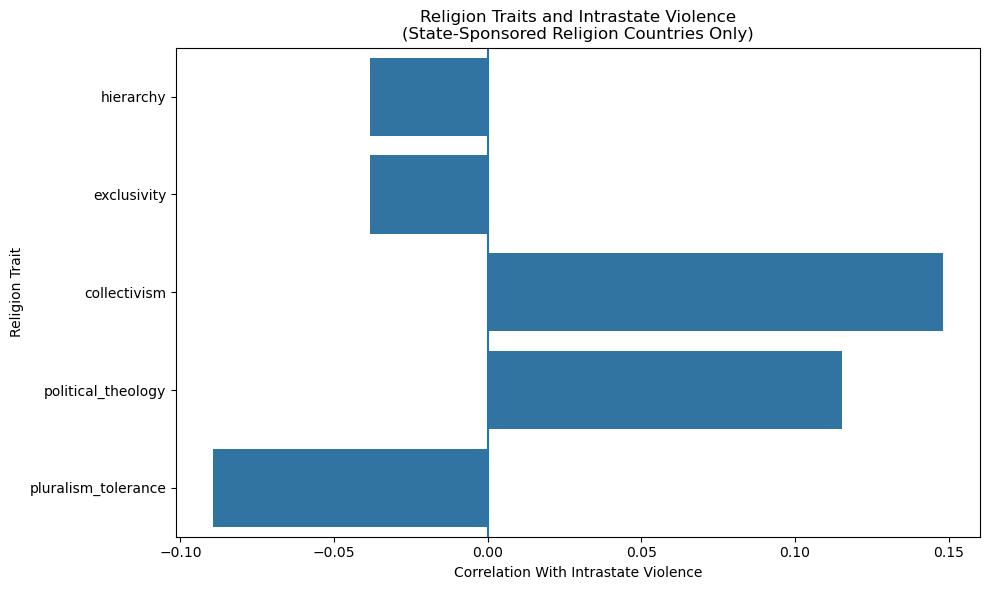

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = correlations.reset_index()
corr_df.columns = [
    "religion_trait",
    "correlation"
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=corr_df,
    x="correlation",
    y="religion_trait"
)

plt.axvline(0)

plt.xlabel(
    "Correlation With Intrastate Violence"
)
plt.ylabel("Religion Trait")

plt.title(
    "Religion Traits and Intrastate Violence\n(State-Sponsored Religion Countries Only)"
)

plt.tight_layout()
plt.show()

In [79]:
religion_counts = (
    final_data2
    .groupby(
        ["majority_religion",
         "state-sponsored religion index"]
    )
    .size()
)

print(religion_counts)

majority_religion         state-sponsored religion index
Buddhists                 0.0                                87
                          2.0                                11
Christians                0.0                               511
                          2.0                                15
Hindus                    0.0                                48
Jews                      2.0                                36
Muslims                   0.0                               349
                          2.0                               343
Religiously_Unaffiliated  0.0                                10
dtype: int64


In [80]:
religion_conflict = (
    final_data2
    .groupby(
        ["majority_religion",
         "state-sponsored religion index"]
    )["intrastate_deaths"]
    .median()
    .reset_index()
)

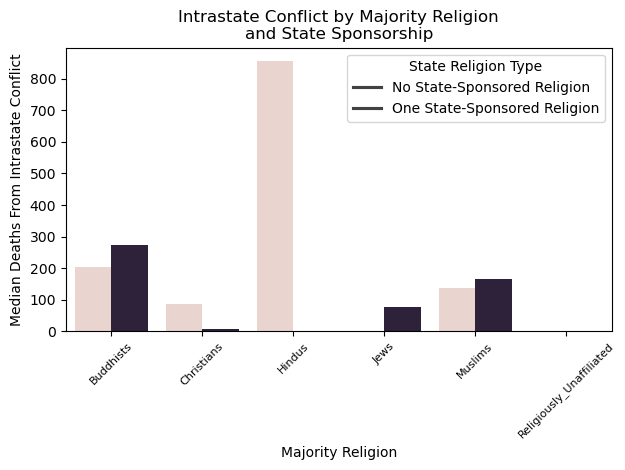

In [81]:
sns.barplot(
    data=religion_conflict,
    x="majority_religion",
    y="intrastate_deaths",
    hue="state-sponsored religion index"
)

plt.ylabel("Median Deaths From Intrastate Conflict")
plt.xlabel("Majority Religion")

plt.title(
    "Intrastate Conflict by Majority Religion\nand State Sponsorship"
)

plt.xticks(rotation=45, fontsize=8)

plt.legend(
    title="State Religion Type",
    labels=[
        "No State-Sponsored Religion",
        "One State-Sponsored Religion"
    ]
)

plt.tight_layout()
plt.show()

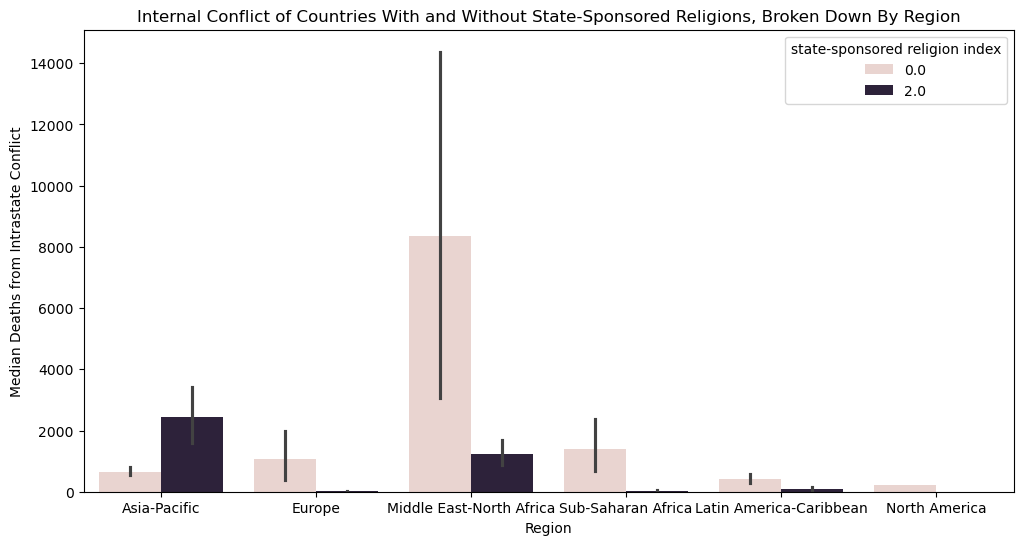

In [84]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = final_data2,
    x = "Region",
    y = "intrastate_deaths",
    hue = "state-sponsored religion index"
)

plt.xlabel("Region")
plt.ylabel("Median Deaths from Intrastate Conflict")
plt.title("Internal Conflict of Countries With and Without State-Sponsored Religions, Broken Down By Region")

plt.show()

# Assistant
This error occurs because the variable `region_conflict` has not been defined or created before it's being used in the `sns.barplot()` function. Additionally, the libraries `plt` (matplotlib.pyplot) and `sns` (seaborn) have not been imported.

**Explanation:**
The code is trying to use:
1. `region_conflict` - a DataFrame that doesn't exist yet
2. `plt` - matplotlib.pyplot that hasn't been imported
3. `sns` - seaborn that hasn't been imported

To fix this, you need to:
1. Import the required libraries
2. Create or load the `region_conflict` DataFrame with the appropriate data and columns

Would you like me to provide the corrected code?

In [82]:
print("Total observations:", final_data2.shape[0])
print("Unique countries:", final_data2["country"].nunique())
print("Year range:", final_data2["year"].min(), "-", final_data2["year"].max())
print("Countries with state religion:", (final_data2["state-sponsored religion index"] == 2).sum())
print("Countries without state religion:", (final_data2["state-sponsored religion index"] != 2).sum())
print("Missing state religion:", final_data2["state-sponsored religion index"].isna().sum())
print("Missing majority religion:", final_data2["majority_religion"].isna().sum())
print("Missing intrastate deaths:", final_data2["intrastate_deaths"].isna().sum())
print("\nObservations by region:")
print(final_data2["Region"].value_counts())
print("\nObservations by majority religion:")
print(final_data2["majority_religion"].value_counts())

Total observations: 1453
Unique countries: 106
Year range: 1989 - 2024
Countries with state religion: 405
Countries without state religion: 1048
Missing state religion: 43
Missing majority religion: 0
Missing intrastate deaths: 0

Observations by region:
Region
Sub-Saharan Africa          493
Asia-Pacific                470
Middle East-North Africa    276
Europe                      113
Latin America-Caribbean     100
North America                 1
Name: count, dtype: int64

Observations by majority religion:
majority_religion
Muslims                     698
Christians                  560
Buddhists                   101
Hindus                       48
Jews                         36
Religiously_Unaffiliated     10
Name: count, dtype: int64


In [89]:
final_data2.groupby(
    ["Region", "state-sponsored religion index"]
).size()

Region                    state-sponsored religion index
Asia-Pacific              0.0                               326
                          2.0                               141
Europe                    0.0                                66
                          2.0                                13
Latin America-Caribbean   0.0                                98
                          2.0                                 2
Middle East-North Africa  0.0                                42
                          2.0                               234
North America             0.0                                 1
Sub-Saharan Africa        0.0                               472
                          2.0                                15
dtype: int64

In [96]:
filtered_by_region = final_data2[
    ~final_data2["Region"].isin([
        "Europe",
        "North America"
    ])
]

final_data3 = (
    filtered_by_region
    .groupby(["Region", "state-sponsored religion index"])
    ["intrastate_deaths"]
    .median()
    .reset_index()
)

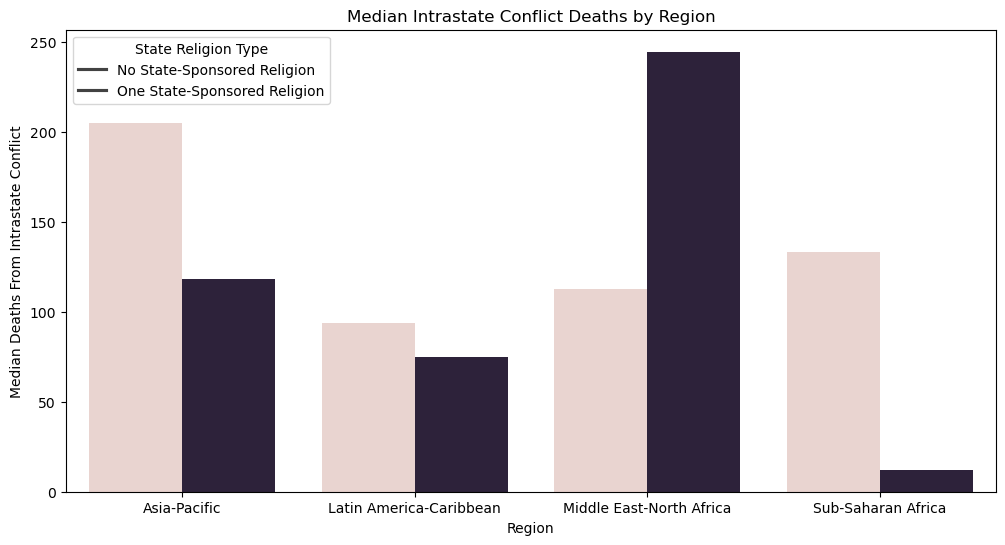

In [97]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_data3,
    x="Region",
    y="intrastate_deaths",
    hue="state-sponsored religion index"
)

plt.ylabel("Median Deaths From Intrastate Conflict")
plt.xlabel("Region")
plt.title(
    "Median Intrastate Conflict Deaths by Region"
)

plt.legend(
    title="State Religion Type",
    labels=[
        "No State-Sponsored Religion",
        "One State-Sponsored Religion"
    ]
)
plt.show()

In [98]:
print(correlations)

hierarchy             -0.038430
exclusivity           -0.038430
collectivism           0.148338
political_theology     0.115171
pluralism_tolerance   -0.089489
Name: log_intrastate_deaths, dtype: float64


In [99]:
print(final_data3.to_string())

                     Region  state-sponsored religion index  intrastate_deaths
0              Asia-Pacific                             0.0              205.0
1              Asia-Pacific                             2.0              118.0
2   Latin America-Caribbean                             0.0               94.0
3   Latin America-Caribbean                             2.0               75.0
4  Middle East-North Africa                             0.0              112.5
5  Middle East-North Africa                             2.0              244.5
6        Sub-Saharan Africa                             0.0              133.0
7        Sub-Saharan Africa                             2.0               12.0
